<a href="https://colab.research.google.com/github/yainma/2026_tues_bigdatacomputing_class/blob/main/%EA%B8%B0%EB%A7%90%EC%8B%9C%ED%97%98_2%EC%B0%A8%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D%EA%B3%BC%EC%A0%9C_20250570%EA%B9%80%EC%B1%84%EC%98%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

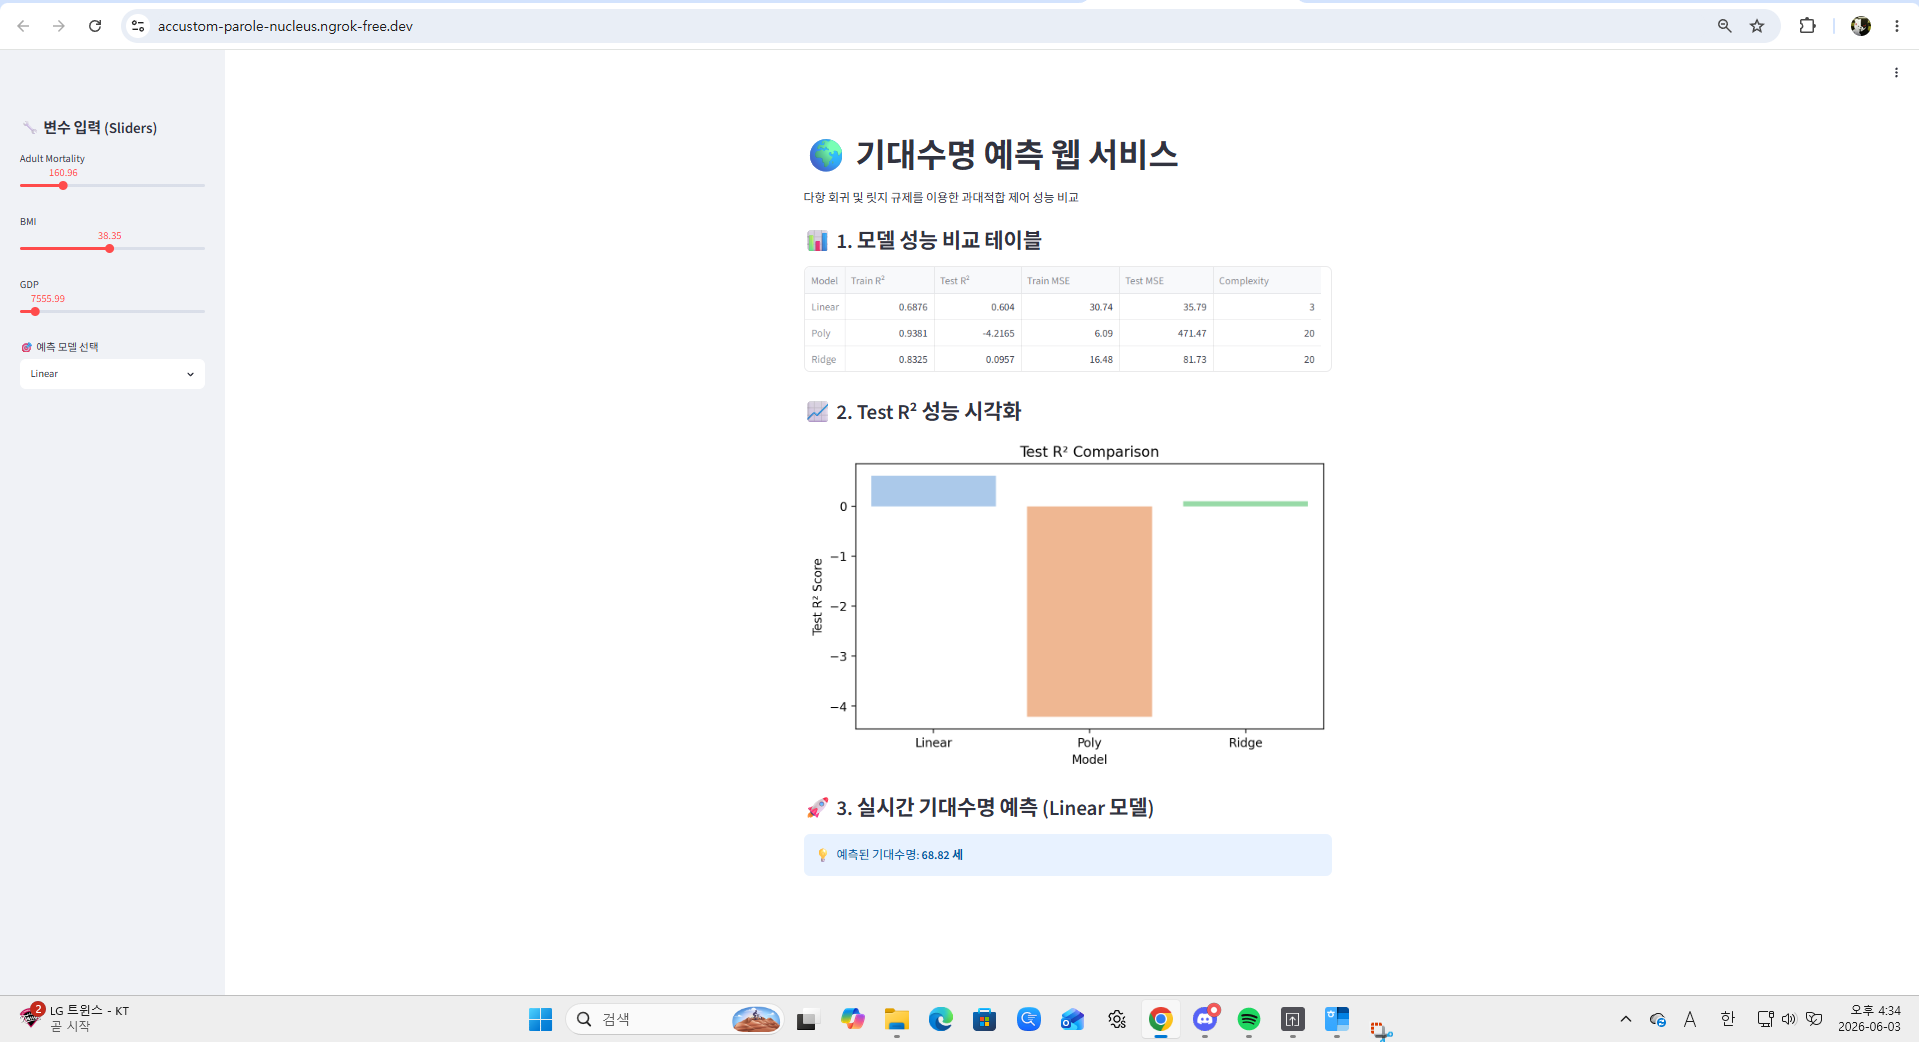

In [ ]:
# 웹 서비스 구동 및 머신러닝 파이프라인 구축을 위한 필수 패키지 일괄 설치
!pip install streamlit pyngrok scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.7 MB/s eta 0:00:00


In [ ]:
#20250570김채영

import pandas as pd                       # 데이터셋(CSV 파일)을 불러오고 행과 열로 조작하는 데이터 분석 라이브러리
import numpy as np                        # 행렬 연산 및 무작위 샘플 추출(np.random)을 위한 수치 계산 라이브러리
import joblib                             # 학습이 완료된 모델 객체를 컴퓨터 하드디스크에 파일(.pkl)로 저장/로드하는 라이브러리
from sklearn.model_selection import train_test_split  # 전체 데이터를 학습용(80%)과 검증용(20%)으로 나누어주는 분할 함수
from sklearn.pipeline import Pipeline     # 전처리 단계(스케일러)와 예측 모델(회귀)을 하나로 묶어주는 파이프라인 클래스
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # 데이터의 단위를 맞추는 스케일러와 데이터를 다항식(차수 확장)으로 변환해주는 전처리 도구
from sklearn.linear_model import LinearRegression, Ridge # 기본적인 선형 회귀 알고리즘과 과대적합을 방지하는 L2 규제(릿지) 회귀 알고리즘

# 1. 데이터 로드 및 전처리
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)

# [KeyError 방지] 컬럼명 앞뒤 공백 제거 후, 중간 공백을 언더바(_)로 치환 및 소문자로 통일
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# 타겟 변수(종속변수: 기대수명) 및 피처 변수(독립변수: 성인사망률, BMI, GDP) 지정
target_col = 'life_expectancy'
feature_cols = ['adult_mortality', 'bmi', 'gdp']

# 분석의 정확도를 위해 지정한 핵심 변수들에 결측치(NaN)가 포함된 행을 일괄 제거
df = df.dropna(subset=[target_col] + feature_cols)

# 모델 학습에 사용할 피처 데이터(X)와 타겟 데이터(y) 분리
X = df[feature_cols]
y = df[target_col]

# 전체 데이터를 학습용 데이터 80%, 검증(테스트)용 데이터 20% 비율로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# [과대적합 시뮬레이션용 데이터 추출] 고의로 과대적합(Overfitting) 환경을 조성하기 위해
# 데이터의 양을 훈련 세트에서 무작위로 딱 50개만 추출 (결과 재현을 위해 렌덤 시드 42 고정)
np.random.seed(42)
idx = np.random.choice(X_train.index, size=50, replace=False)
X_train_50 = X_train.loc[idx]
y_train_50 = y_train.loc[idx]

# 2. 분석 모델 파이프라인(Pipeline) 구축

# [모델 1] 단순 선형 회귀 파이프라인: 표준화 스케일링 수행 후 표준 선형 회귀 적용
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# [모델 2] 다항 회귀 파이프라인: 피처를 3차 다항식(degree=3)으로 확장한 후 표준화 및 회귀 적용 (과대적합 유도)
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# [모델 3] 릿지 회귀 파이프라인: 3차 다항식 확장 및 스케일링 후, L2 규제(alpha=1.0)를 더해 과대적합을 방어
pipe_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0))
])

# 3. 모델 학습 및 피클(Pickle) 저장
# 생성한 3가지 모델을 딕셔너리로 묶어 반복문을 돌며 순서대로 학습 진행
models = {'Linear': pipe_linear, 'Poly': pipe_poly, 'Ridge': pipe_ridge}
for name, model in models.items():
    # 앞서 추출한 50개의 소규모 학습용 데이터셋으로 모델을 피팅(학습)
    model.fit(X_train_50, y_train_50)

    # 학습이 완료된 모델 객체를 웹 서비스(Streamlit)에서 실시간으로 불러올 수 있도록 .pkl 파일로 저장
    joblib.dump(model, f'model_{name.lower()}.pkl')

print("✅ 3종 모델 학습 및 저장 완료 (.pkl)")

✅ 3종 모델 학습 및 저장 완료 (.pkl)


In [ ]:
# 이 셀의 전체 코드를 'app.py'라는 이름의 파이썬 파일로 저장하는 주피터 노트북(Colab) 매직 명령어
%%writefile app.py
import streamlit as st                  # 슬라이더, 테이블, 말풍선 등 웹 브라우저 화면 UI를 쉽게 빌드해주는 대시보드 라이브러리
import pandas as pd                     # Streamlit 내부에서 원본 데이터셋을 로드하고 컬럼명을 전처리하는 데이터 핸들링 라이브러리
import numpy as np                      # 데이터셋 분할을 위한 랜덤 시드 설정 및 행렬 연산을 지원하는 수치 계산 라이브러리
import joblib                           # 이전 셀에서 저장한 3종 머신러닝 모델 파일(.pkl)을 웹 서버로 불러오는 파일 로드 라이브러리
import matplotlib.pyplot as plt         # 웹 화면에 표시할 차트와 바 그래프의 캔버스(틀)를 생성하는 기본 시각화 라이브러리
import seaborn as sns                   # 모델별 Test R² 점수를 세련되고 직관적인 막대그래프로 그려주는 데이터 시각화 라이브러리
from sklearn.model_selection import train_test_split  # 데이터 학습 조건(50개 추출 등)을 동일하게 복제하기 위한 데이터 분할 함수
from sklearn.metrics import r2_score, mean_squared_error # 각 모델의 설명력(R²)과 평균제곱오차(MSE) 성능 지표를 실시간 계산하는 평가 함수

# 데이터 로드 (성능 평가용)
@st.cache_data  # Streamlit이 웹 앱을 재실행할 때마다 데이터를 새로 다운로드하지 않고, 메모리에 저장(캐싱)해두어 속도를 높여주는 데코레이터
def load_data():
    # 1. 원본 데이터셋 로드 및 컬럼명 공백/대소문자 처리
    url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

    # 2. 분석에 사용할 변수 지정 및 결측치 제거
    target_col = 'life_expectancy'
    feature_cols = ['adult_mortality', 'bmi', 'gdp']
    df = df.dropna(subset=[target_col] + feature_cols)

    # 3. 독립변수(X)와 종속변수(y) 분리
    X = df[feature_cols]
    y = df[target_col]

    # 4. 모델 학습 때와 완전히 동일하게 데이터셋 분할 (80% 학습, 20% 테스트)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. 과대적합 성능을 똑같이 평가하기 위해 학습 데이터 중 무작위 50개 샘플을 추출하는 과정 복제
    np.random.seed(42)  # 랜덤 시드를 42로 고정하여 동일한 50개 샘플이 추출되도록 함
    idx = np.random.choice(X_train.index, size=50, replace=False)
    X_train_50 = X_train.loc[idx]
    y_train_50 = y_train.loc[idx]

    # 웹 화면 전체에서 재사용할 수 있도록 정제 및 분할이 완료된 데이터셋들을 반환
    return X, X_train_50, X_test, y_train_50, y_test

# 작성한 load_data() 함수를 실행하여, 반환된 데이터셋들을 각각의 변수에 저장
X_full, X_train_50, X_test, y_train_50, y_test = load_data()

# 모델 로드
# 앞서 파일로 저장해둔 선형, 다항, 릿지 회귀 모델(.pkl)을 joblib으로 로드하여 딕셔너리에 저장
models = {
    'Linear': joblib.load('model_linear.pkl'),
    'Poly': joblib.load('model_poly.pkl'),
    'Ridge': joblib.load('model_ridge.pkl')
}

# 웹 대시보드 상단 제목 및 서비스 설명 텍스트 출력
st.title("🌍 기대수명 예측 웹 서비스")
st.write("다항 회귀 및 릿지 규제를 이용한 과대적합 제어 성능 비교")

# 1. 성능 평가지표 계산
results = [] # 각 모델의 평가지표 결과를 딕셔너리 형태로 저장할 빈 리스트 생성

# 저장된 3개의 모델을 하나씩 꺼내어 성능을 평가하는 반복문 실행
for name, model in models.items():
    # 학습에 사용된 소규모 데이터(50개)와 한 번도 보지 못한 테스트 데이터(20%)에 대한 예측 수행
    y_train_pred = model.predict(X_train_50)
    y_test_pred = model.predict(X_test)

    # [모델 복잡도(Complexity) 계산] 모델이 사용한 총 피처(변수)의 개수를 구하는 로직
    if name == 'Linear':
        # 단순 선형 회귀는 기본 독립변수의 개수(3개)가 곧 모델 복잡도임
        complexity = X_train_50.shape[1]
    else:
        # 다항 회귀와 릿지는 3차 다항식 확장 변환(PolynomialFeatures)을 거쳤으므로,
        # 파이프라인 내부의 'poly' 단계를 통해 확장된 이후의 최종 피처 개수를 동적으로 계산
        complexity = model.named_steps['poly'].transform(X_train_50.iloc[[0]]).shape[1]

    # 계산된 성능 지표들을 딕셔너리 구조로 만들어 리스트에 추가 (소수점 자릿수 정리)
    results.append({
        'Model': name,                                                        # 모델 이름 (Linear, Poly, Ridge)
        'Train R²': round(r2_score(y_train_50, y_train_pred), 4),             # 훈련 데이터 결정계수 (설명력)
        'Test R²': round(r2_score(y_test, y_test_pred), 4),                   # 테스트 데이터 결정계수 (예측력)
        'Train MSE': round(mean_squared_error(y_train_50, y_train_pred), 2),   # 훈련 데이터 평균제곱오차 (에러율)
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 2),         # 테스트 데이터 평균제곱오차 (에러율)
        'Complexity': complexity                                              # 모델의 복잡도 (피처 수)
    })

# 수집된 리스트 데이터를 표 형태로 시각화하기 위해 판다스 데이터프레임(DataFrame)으로 변환
# 표의 행 인덱스(가장 왼쪽 기준축)를 'Model'로 지정하여 깔끔하게 정렬
df_results = pd.DataFrame(results).set_index('Model')

# 성능 비교 섹션 렌더링
# 메인 화면에 첫 번째 서브 타이틀(텍스트)을 생성
st.subheader("📊 1. 모델 성능 비교 테이블")
# 위에서 구축한 3종 모델의 평가지표 데이터프레임(df_results)을 대시보드에 표 형태로 출력
st.dataframe(df_results)

# 메인 화면에 두 번째 서브 타이틀(텍스트)을 생성
st.subheader("📈 2. Test R² 성능 시각화")
# Matplotlib을 이용해 그래프를 그릴 7x4 인치 크기의 도화지(fig)와 축(ax) 세트 생성
fig, ax = plt.subplots(figsize=(7, 4))
# Seaborn의 barplot을 활용해 x축은 모델 이름, y축은 Test R² 점수로 구성된 막대그래프 렌더링 (파스텔 톤 색상 적용)
sns.barplot(x=df_results.index, y=df_results['Test R²'], palette='pastel', ax=ax)
ax.set_ylabel('Test R² Score')   # y축 레이블 이름 설정
ax.set_title('Test R² Comparison') # 그래프 자체의 상단 제목 설정
# 완성이 완료된 Matplotlib plot(fig)을 Streamlit 웹 화면에 최종 표출
st.pyplot(fig)

# 2. 사이드바 및 실시간 예측 UI
# 웹 화면 왼쪽 접이식 사이드바 영역에 대제목 생성
st.sidebar.header("🔧 변수 입력 (Sliders)")

# [사이드바 슬라이더 구축] 각 변수의 최솟값, 최댓값 범위를 지정하고 기본 배치값을 원본 데이터의 평균값(mean)으로 설정
adult_mortality = st.sidebar.slider("Adult Mortality", float(X_full['adult_mortality'].min()), float(X_full['adult_mortality'].max()), float(X_full['adult_mortality'].mean()))
bmi = st.sidebar.slider("BMI", float(X_full['bmi'].min()), float(X_full['bmi'].max()), float(X_full['bmi'].mean()))
gdp = st.sidebar.slider("GDP", float(X_full['gdp'].min()), float(X_full['gdp'].max()), float(X_full['gdp'].mean()))

# [사이드바 드롭다운 박스] 사용자가 실시간 예측에 활용할 알고리즘을 선택할 수 있는 선택창 구현
selected_model_name = st.sidebar.selectbox("🎯 예측 모델 선택", ['Linear', 'Poly', 'Ridge'])

# 메인 화면 하단에 현재 선택된 모델명이 동적으로 표기되는 세 번째 서브 타이틀 생성
st.subheader(f"🚀 3. 실시간 기대수명 예측 ({selected_model_name} 모델)")

# 사용자가 왼쪽 슬라이더를 통해 변경 지정한 가상의 수치들을 머신러닝 모델의 입력 양식(1행 3열의 데이터프레임)으로 래핑
user_data = pd.DataFrame({'adult_mortality': [adult_mortality], 'bmi': [bmi], 'gdp': [gdp]})

# 결과 출력
# 사용자가 선택한 모델(selected_model_name)을 딕셔너리에서 매칭하여 가져온 뒤, 사용자 데이터(user_data)를 대입해 실시간 예측값(수치) 도출
prediction = models[selected_model_name].predict(user_data)[0]

# 예측 완료된 기대수명(세) 값을 소수점 둘째 자리까지 포맷팅하여 메인 화면 파란색 정보 안내 상자(st.info) 안에 큼직하게 강조 표기
st.info(f"💡 예측된 기대수명: **{prediction:.2f} 세**")

Writing app.py


In [ ]:
from pyngrok import ngrok  # 파이썬 환경에서 ngrok 프로그램을 제어하여 코랩 내부 포트(8501)를 외부 접속 가능한 공인 URL 주소로 변환 및 매핑해주는 배포 라이브러리
import os                  # 백그라운드 환경에서 Streamlit 서버를 독립적으로 구동하거나(nohup 명령어 등) 파일 시스템, 환경 변수 등 리눅스 운영체제(OS) 명령을 파이썬 내부에서 실행할 수 있게 돕는 라이브러리

# 이전에 열려있는 포트가 있다면 닫기
ngrok.kill()

# ngrok 토큰 설정
ngrok.set_auth_token("3Ec56iv7pfpMWwDx2UrJhe2k4Bk_nWaGkEYbiDRMeM3ZqTh9")

# Streamlit 백그라운드 실행
os.system("nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &")

# 8501 포트 터널링
public_url = ngrok.connect(8501)
print(f"✅ 웹 서비스가 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")

✅ 웹 서비스가 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://accustom-parole-nucleus.ngrok-free.dev" -> "http://localhost:8501"
